# Loyalty Member Segmentation: Finding Points-Purchase Targets

**Business question:** Are the members most engaged with the airline also the most likely to buy points? Within that group, who is the easiest next buyer to win?

**Approach**
1. Combine four sources (member profile, flight transactions, points purchases, marketing history) into one row per member.
2. Segment members with **K-Means clustering on airline transactional data only**: flights, spend, cabin, routes, points earned and redeemed. Points purchases are **held out** of the clustering.
3. Profile the segments and visualize their activity and traits.
4. Measure the **north-star KPI**, the *share of members who bought points*, for each segment. This tests whether airline engagement predicts points buying.
5. Within the top segment, pull out members who have **never bought points** and **were never on our email list**. These are the lowest-hanging fruit. Rank them with a look-alike propensity score.

> The data is **synthetic** (see `generate_data.py`). It copies the structure of a real partner dataset, which is confidential.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)

# Validated categorical palette (fixed order) and chart styling
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLUES = ["#cde2fb", "#86b6ef", "#2a78d6", "#184f95"]   # sequential ramp for ordered categories
SURFACE, INK, INK_2, GRID, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#b9b8b2"
DIVERGING = sns.diverging_palette(250, 25, s=80, l=55, as_cmap=True)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True, "font.size": 10,
})

FIGURES = Path("figures"); FIGURES.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=130, bbox_inches="tight")

DATA = Path("data")
SNAPSHOT = pd.Timestamp("2025-12-31")   # "today" for the analysis
WINDOW_START = pd.Timestamp("2024-01-01")
RANDOM_STATE = 42

## 1. Load the data
If the CSVs are missing, they are regenerated from the seeded generator.

In [2]:
if not (DATA / "members.csv").exists():
    import subprocess, sys
    subprocess.run([sys.executable, "generate_data.py"], check=True)

members = pd.read_csv(DATA / "members.csv", parse_dates=["enrol_date"])
flights = pd.read_csv(DATA / "flights.csv.gz", parse_dates=["booking_date", "departure_date", "return_date"])
purchases = pd.read_csv(DATA / "points_purchases.csv", parse_dates=["purchase_date"])
contacts = pd.read_csv(DATA / "marketing_contacts.csv.gz", parse_dates=["send_date"])

for name, df in [("members", members), ("flights", flights), ("purchases", purchases), ("contacts", contacts)]:
    print(f"{name:<10} {df.shape[0]:>8,} rows  x {df.shape[1]} cols")

members      40,000 rows  x 7 cols
flights     180,080 rows  x 14 cols
purchases    22,964 rows  x 7 cols
contacts     22,571 rows  x 6 cols


In [3]:
members.head()

,member_id,enrol_date,tier,age_band,home_airport,email_opt_in,points_balance
0,M0000001,2023-04-22,Base,35-44,YYC,True,16451
1,M0000002,2021-10-26,Silver,45-54,YYZ,False,3672
2,M0000003,2019-07-01,Base,45-54,YYZ,True,489
3,M0000004,2021-08-26,Base,45-54,YVR,True,14668
4,M0000005,2015-02-22,Base,35-44,YUL,True,9082


In [4]:
flights.head()

,booking_id,member_id,booking_date,departure_date,return_date,origin,destination,route_type,cabin_class,payment_type,fare_cad,fare_points,taxes_fees_cad,points_earned
0,B00000001,M0000006,2024-01-10,2024-01-31,2024-02-03,YUL,YOW,Domestic,Economy,Cash,801.75,0,0.00,1604
1,B00000002,M0000006,2024-02-27,2024-03-07,2024-03-13,YUL,YHZ,Domestic,Business,Cash,"2,691.63",0,0.00,13458
2,B00000003,M0000006,2024-02-28,2024-03-30,2024-04-08,YUL,SFO,Transborder,Economy,Cash,"1,289.29",0,0.00,2579
3,B00000004,M0000006,2024-03-06,2024-03-21,2024-03-27,YUL,LAS,Transborder,Business,Cash,"3,199.51",0,0.00,15998
4,B00000005,M0000006,2024-06-14,2024-07-12,2024-07-20,YUL,LAX,Transborder,Business,Cash,"4,052.87",0,0.00,20264


In [5]:
purchases.head()

,transaction_id,member_id,purchase_date,points_purchased,bonus_points,amount_usd,promo_flag
0,T0000001,M0000013,2024-12-11,25000,7500,549.89,True
1,T0000002,M0000014,2024-05-06,32000,0,969.13,False
2,T0000003,M0000014,2025-03-05,13000,9100,299.38,True
3,T0000004,M0000022,2024-09-01,8000,0,237.34,False
4,T0000005,M0000025,2024-04-28,12000,0,346.91,False


## 2. Data quality checks
Before engineering features: check nulls, duplicates, impossible dates and orphaned keys.

In [6]:
checks = {
    "duplicate member_id": members["member_id"].duplicated().sum(),
    "duplicate booking_id": flights["booking_id"].duplicated().sum(),
    "flights with unknown member": (~flights["member_id"].isin(members["member_id"])).sum(),
    "purchases with unknown member": (~purchases["member_id"].isin(members["member_id"])).sum(),
    "return before departure": (flights["return_date"] < flights["departure_date"]).sum(),
    "departure before booking": (flights["departure_date"] < flights["booking_date"]).sum(),
    "award flights with cash fare": ((flights["payment_type"] == "Points") & (flights["fare_cad"] > 0)).sum(),
    "negative points balance": (members["points_balance"] < 0).sum(),
}
pd.Series(checks, name="count").to_frame()

,count
duplicate member_id,0
duplicate booking_id,0
flights with unknown member,0
purchases with unknown member,0
return before departure,0
departure before booking,0
award flights with cash fare,0
negative points balance,0


In [7]:
# One-way trips have no return date, so these nulls are expected
flights.isna().sum()[lambda s: s > 0]

return_date    36192
dtype: int64

## 3. Feature engineering
Each member becomes one row, covering the 24 months to 2025-12-31.

| Group | Features | Used for |
|---|---|---|
| **Airline activity** (shared by the airline) | flights, cash spend, avg fare, points earned, points redeemed, award-flight share, premium-cabin share, international share, booking lead time, trip length, days since last booking, tier | **Clustering** |
| **Points buying** (our own data) | purchases, points bought, $ spent, promo share, days since last purchase | **Evaluation only**: the KPI |
| **Marketing** | ever received a points email | Target-list filter |

In [8]:
TIER_ORDER = {"Base": 0, "Silver": 1, "Gold": 2, "Platinum": 3, "Elite": 4}

f = flights[flights["booking_date"].between(WINDOW_START, SNAPSHOT)].copy()
f["is_award"] = f["payment_type"].eq("Points")
f["is_premium"] = f["cabin_class"].ne("Economy")
f["is_intl"] = f["route_type"].eq("International")
f["lead_days"] = (f["departure_date"] - f["booking_date"]).dt.days
f["trip_days"] = (f["return_date"] - f["departure_date"]).dt.days

airline = f.groupby("member_id").agg(
    flights=("booking_id", "count"),
    award_flights=("is_award", "sum"),
    cash_spend_cad=("fare_cad", "sum"),
    points_earned=("points_earned", "sum"),
    points_redeemed=("fare_points", "sum"),
    premium_cabin_share=("is_premium", "mean"),
    intl_share=("is_intl", "mean"),
    avg_lead_days=("lead_days", "mean"),
    avg_trip_days=("trip_days", "mean"),
    last_booking=("booking_date", "max"),
)
airline["avg_cash_fare_cad"] = f[~f["is_award"]].groupby("member_id")["fare_cad"].mean()

buying = purchases.groupby("member_id").agg(
    purchases=("transaction_id", "count"),
    points_bought=("points_purchased", "sum"),
    purchase_spend_usd=("amount_usd", "sum"),
    promo_share=("promo_flag", "mean"),
    last_purchase=("purchase_date", "max"),
)

features = members.set_index("member_id").join([airline, buying])
zero_fill = ["flights", "award_flights", "cash_spend_cad", "points_earned", "points_redeemed",
             "premium_cabin_share", "intl_share", "avg_lead_days", "avg_trip_days", "avg_cash_fare_cad",
             "purchases", "points_bought", "purchase_spend_usd", "promo_share"]
features[zero_fill] = features[zero_fill].fillna(0)
features["award_share"] = features["award_flights"] / features["flights"].where(features["flights"] > 0)
features["award_share"] = features["award_share"].fillna(0)
# Recency: members with no activity get 731 days (i.e. "longer ago than the 24-month window")
features["days_since_booking"] = (SNAPSHOT - features["last_booking"]).dt.days.fillna(731)
features["days_since_purchase"] = (SNAPSHOT - features["last_purchase"]).dt.days.fillna(731)
features["tier_rank"] = features["tier"].map(TIER_ORDER)
features["tenure_years"] = (SNAPSHOT - features["enrol_date"]).dt.days / 365.25

# KPI and marketing flags
features["bought_points"] = features["purchases"] > 0
features["ever_emailed"] = features.index.isin(contacts["member_id"])
features = features.drop(columns=["last_booking", "last_purchase"])
features.describe().T

,count,mean,min,25%,50%,75%,max,std
enrol_date,40000,2015-12-25 19:22:35.040000,2008-01-01 00:00:00,2011-12-25 00:00:00,2015-12-28 00:00:00,2019-12-25 00:00:00,2023-12-31 00:00:00,NaN
points_balance,"40,000.00","24,700.65",0.00,"2,876.00","9,908.50","21,189.25","1,376,246.00","58,261.53"
flights,"40,000.00",4.50,0.00,0.00,1.00,4.00,181.00,9.38
award_flights,"40,000.00",0.77,0.00,0.00,0.00,0.00,29.00,2.05
cash_spend_cad,"40,000.00","6,644.65",0.00,0.00,936.95,"4,444.67","321,280.03","18,083.03"
points_earned,"40,000.00","23,666.03",0.00,0.00,"1,893.00","10,069.00","1,211,201.00","73,351.17"
points_redeemed,"40,000.00","68,297.52",0.00,0.00,0.00,0.00,"3,184,000.00","208,206.77"
premium_cabin_share,"40,000.00",0.12,0.00,0.00,0.00,0.17,1.00,0.23
intl_share,"40,000.00",0.14,0.00,0.00,0.00,0.25,1.00,0.24
avg_lead_days,"40,000.00",42.36,0.00,0.00,40.75,69.40,347.00,41.93


### Distributions
The activity metrics are heavily right-skewed: most members fly rarely and a small group flies a lot. K-Means uses Euclidean distance, so these features get a `log1p` transform before scaling. Without it, a handful of extreme members would drive the clusters.

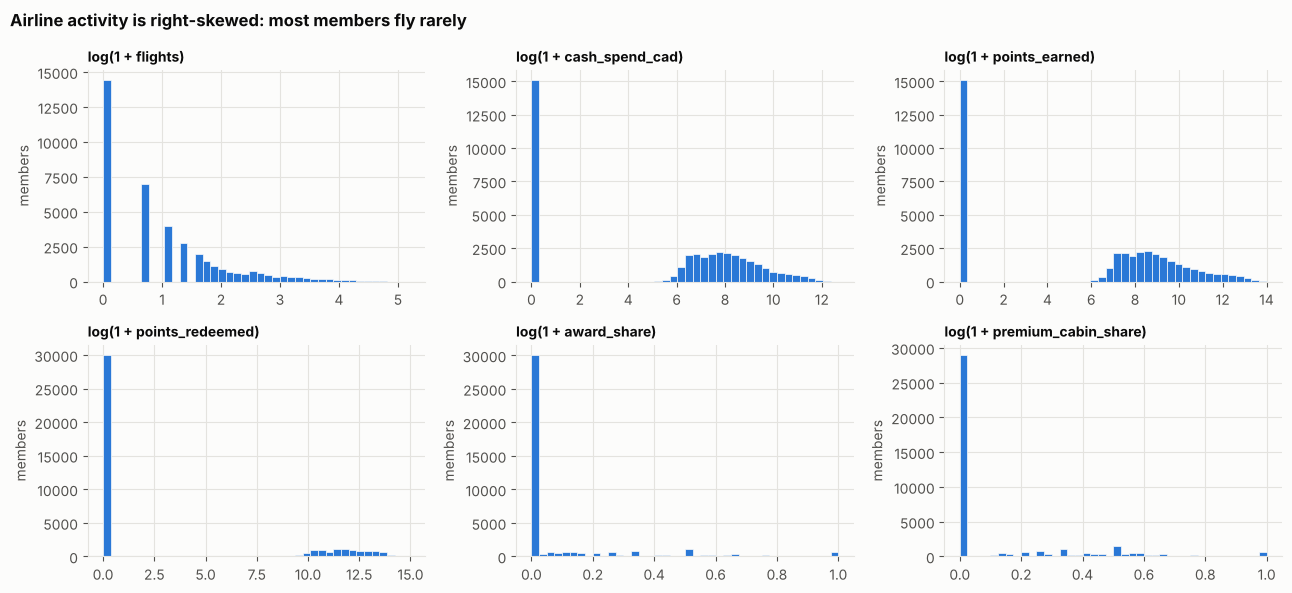

In [9]:
show = ["flights", "cash_spend_cad", "points_earned", "points_redeemed", "award_share", "premium_cabin_share"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, show):
    vals = np.log1p(features[col]) if col in ["flights", "cash_spend_cad", "points_earned", "points_redeemed"] else features[col]
    label = f"log(1 + {col})" if vals is not features[col] else col
    ax.hist(vals, bins=40, color=PALETTE[0], edgecolor=SURFACE, linewidth=0.5)
    ax.set_title(label, fontsize=10); ax.set_ylabel("members")
fig.suptitle("Airline activity is right-skewed: most members fly rarely", x=0.01, ha="left",
             fontweight="bold", color=INK)
plt.tight_layout()

## 4. Clustering features: airline data only
Points-purchase features are left out on purpose. If they were included, the clusters would be defined by buying, and "the top segment buys the most" would be circular. Clustering on airline behaviour alone lets the points-purchase KPI act as an **independent test**: do airline-engaged members buy more points?

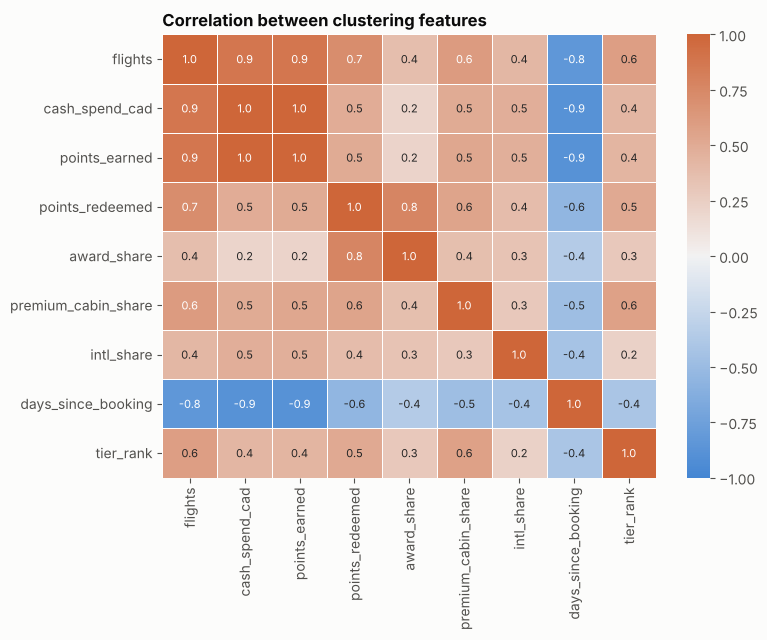

In [10]:
cluster_features = [
    "flights", "cash_spend_cad", "points_earned", "points_redeemed", "award_share",
    "premium_cabin_share", "intl_share", "days_since_booking", "tier_rank",
]
log_cols = ["flights", "cash_spend_cad", "points_earned", "points_redeemed"]

X = features[cluster_features].copy()
X[log_cols] = np.log1p(X[log_cols])
X_scaled = StandardScaler().fit_transform(X)

plt.figure(figsize=(8, 6.5))
sns.heatmap(pd.DataFrame(X, columns=cluster_features).corr(), cmap=DIVERGING, center=0, vmin=-1, vmax=1,
            annot=True, fmt=".1f", annot_kws={"size": 8}, linewidths=0.5)
plt.title("Correlation between clustering features"); plt.grid(False)
plt.tight_layout()

## 5. Choosing the number of clusters
Two diagnostics:
- **Elbow (inertia):** the within-cluster sum of squares always falls as *k* grows. We look for the point where the gains flatten.
- **Silhouette score:** how well separated the clusters are, from -1 to 1. Computed on a 10k sample to save time.

The pick also has to be **actionable**: a handful of personas that marketing can act on.

k,2,3,4,5,6,7,8,9
inertia,"203,712.71","133,445.57","107,267.62","89,878.76","78,523.70","69,714.88","61,601.33","55,876.94"
silhouette,0.44,0.54,0.55,0.56,0.57,0.57,0.59,0.58


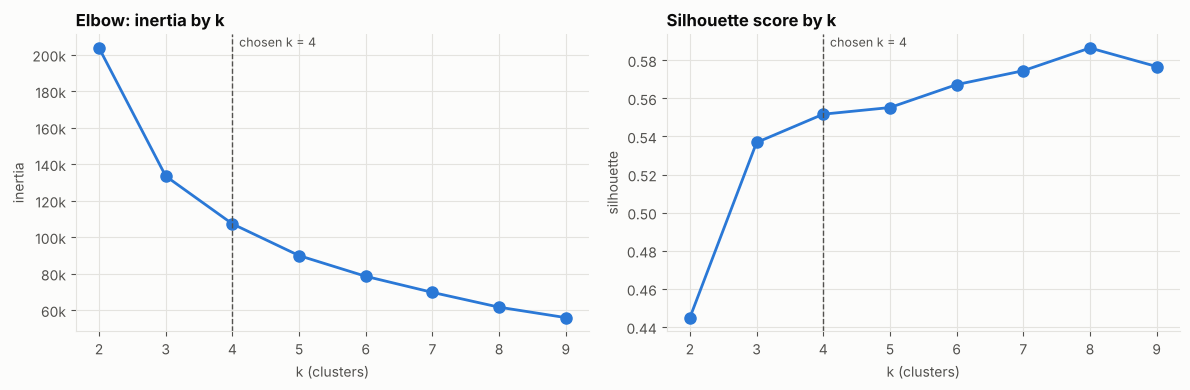

In [11]:
ks = range(2, 10)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_, sample_size=10_000, random_state=RANDOM_STATE))

K = 4
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(ks, inertia, marker="o", color=PALETTE[0], lw=2, ms=8)
a1.set(title="Elbow: inertia by k", xlabel="k (clusters)", ylabel="inertia")
a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
a2.plot(ks, silhouette, marker="o", color=PALETTE[0], lw=2, ms=8)
a2.set(title="Silhouette score by k", xlabel="k (clusters)", ylabel="silhouette")
for a in (a1, a2):
    a.axvline(K, color=INK_2, ls="--", lw=1)
    a.text(K + 0.1, a.get_ylim()[1], f"chosen k = {K}", va="top", color=INK_2, fontsize=9)
plt.tight_layout()
pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": silhouette}).set_index("k").T

Inertia drops steeply up to **k = 4** and flattens after it. The silhouette score also jumps up to k = 4, and later gains are small. Higher *k* splits the light flyers into near-identical slivers. **We use k = 4.**

In [12]:
kmeans = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE).fit(X_scaled)
features["cluster"] = kmeans.labels_
features["cluster"].value_counts().sort_index()

cluster
0    14432
1    14762
2     6846
3     3960
Name: count, dtype: int64

## 6. Profile and name the segments

In [13]:
profile = features.groupby("cluster")[cluster_features + ["avg_cash_fare_cad", "avg_lead_days"]].mean()
profile.insert(0, "members", features["cluster"].value_counts())
profile.T

cluster,0,1,2,3
members,"14,432.00","14,762.00","6,846.00","3,960.00"
flights,0.00,2.47,7.41,23.46
cash_spend_cad,0.00,"2,746.49","7,078.23","44,642.60"
points_earned,0.00,"6,452.41","21,174.05","178,392.24"
points_redeemed,0.00,1.67,"261,615.00","237,590.91"
award_share,0.00,0.00,0.45,0.14
premium_cabin_share,0.00,0.07,0.24,0.54
intl_share,0.00,0.17,0.32,0.24
days_since_booking,731.00,264.26,133.09,56.54
tier_rank,0.05,0.13,0.58,2.50


In [14]:
# Name clusters by ranking their centroids on AIRLINE traits only, not by hard-coded IDs,
# so labels stay correct if K-Means numbers the clusters differently.
names, remaining = {}, profile.copy()
for rule, name in [(lambda d: d["flights"].idxmin(), "Dormant"),
                   (lambda d: d["award_share"].idxmax(), "Engaged Points Buyers"),
                   (lambda d: d["flights"].idxmax(), "Frequent Premium Flyers"),
                   (lambda d: d.index[0], "Light Leisure Flyers")]:
    idx = rule(remaining)
    names[idx] = name
    remaining = remaining.drop(idx)
features["segment"] = features["cluster"].map(names)

# Fixed segment order (and therefore fixed colours) used by every chart below
SEGMENTS = ["Engaged Points Buyers", "Frequent Premium Flyers", "Light Leisure Flyers", "Dormant"]
SEG_COLOR = dict(zip(SEGMENTS, PALETTE))
TOP_SEGMENT = "Engaged Points Buyers"
seg_profile = features.groupby("segment")[cluster_features].mean().loc[SEGMENTS]
seg_profile.insert(0, "members", features["segment"].value_counts())
seg_profile.insert(1, "pct_of_base", seg_profile["members"] / len(features))
seg_profile

,members,pct_of_base,flights,cash_spend_cad,points_earned,points_redeemed,award_share,premium_cabin_share,intl_share,days_since_booking,tier_rank
segment,,,,,,,,,,,
Engaged Points Buyers,6846,0.17,7.41,"7,078.23","21,174.05","261,615.00",0.45,0.24,0.32,133.09,0.58
Frequent Premium Flyers,3960,0.10,23.46,"44,642.60","178,392.24","237,590.91",0.14,0.54,0.24,56.54,2.50
Light Leisure Flyers,14762,0.37,2.47,"2,746.49","6,452.41",1.67,0.00,0.07,0.17,264.26,0.13
Dormant,14432,0.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00,731.00,0.05


| Segment | Who they are (airline behaviour only) |
|---|---|
| **Engaged Points Buyers** | Fly regularly and are the most active on the points side of the airline relationship. They book roughly half their trips as award flights, often international and premium cabin, so they earn *and* burn. (The name reflects what section 8 finds about their points buying.) |
| **Frequent Premium Flyers** | Highest flight volume, cash spend and tier; mostly business and premium-economy travellers. They earn a lot but book mostly with cash. |
| **Light Leisure Flyers** | A few economy trips a year, almost all paid in cash; small balances. |
| **Dormant** | No flight activity in the last 24 months. |

## 7. Visualizing the segments
### 7a. Where the segments sit
PCA reduces the 9 clustering features to 2 dimensions so the clusters can be plotted. The labelled point marks each segment's centre.

,cash_spend_cad,points_earned,flights,intl_share,premium_cabin_share,tier_rank,days_since_booking,points_redeemed,award_share
PC2 loading,-0.36,-0.35,-0.10,0.00,0.17,0.20,0.23,0.45,0.64


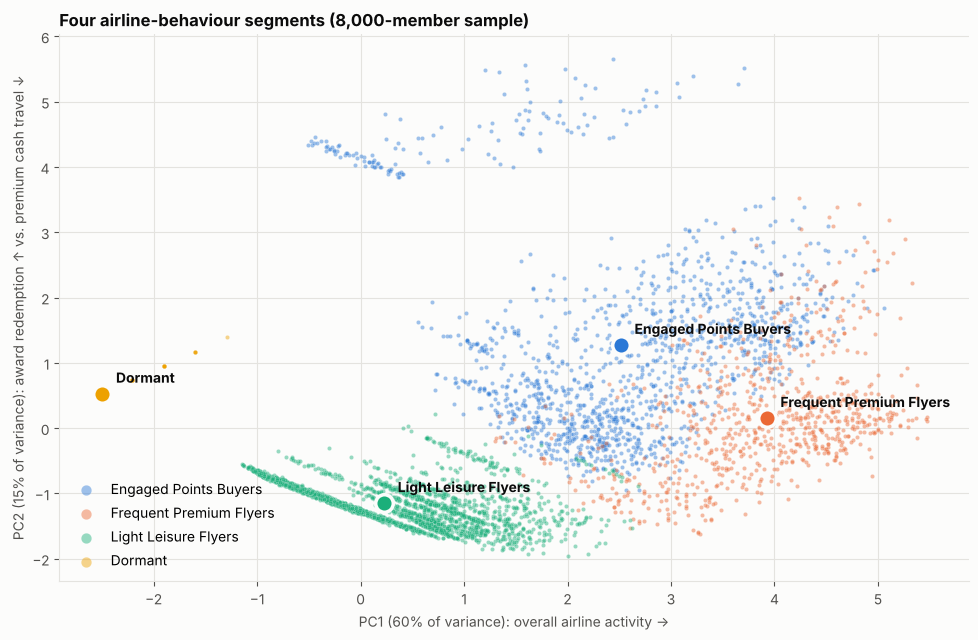

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
sample = np.random.default_rng(RANDOM_STATE).choice(len(pcs), 8000, replace=False)
seg_arr = features["segment"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6.5))
for seg in SEGMENTS:
    idx = sample[seg_arr[sample] == seg]
    ax.scatter(pcs[idx, 0], pcs[idx, 1], s=9, alpha=0.45, color=SEG_COLOR[seg], label=seg,
               edgecolors=SURFACE, linewidths=0.2)
for seg in SEGMENTS:
    cx, cy = pcs[seg_arr == seg].mean(axis=0)
    ax.scatter(cx, cy, s=160, color=SEG_COLOR[seg], edgecolors=SURFACE, linewidths=2.5, zorder=3)
    ax.annotate(seg, (cx, cy), xytext=(10, 8), textcoords="offset points", fontsize=10,
                fontweight="bold", color=INK, zorder=4)
ev = pca.explained_variance_ratio_
loadings = pd.Series(pca.components_[1], index=cluster_features)
ax.set(xlabel=f"PC1 ({ev[0]:.0%} of variance): overall airline activity →",
       ylabel=f"PC2 ({ev[1]:.0%} of variance): award redemption ↑ vs. premium cash travel ↓",
       title="Four airline-behaviour segments (8,000-member sample)")
ax.legend(frameon=False, markerscale=2.5, loc="lower left")
plt.tight_layout(); save(fig, "segments_pca")
loadings.sort_values().round(2).to_frame("PC2 loading").T

### 7b. Segment fingerprint
Each cell shows how far the segment's average sits from the member average, in standard deviations. Orange is above average and blue is below.

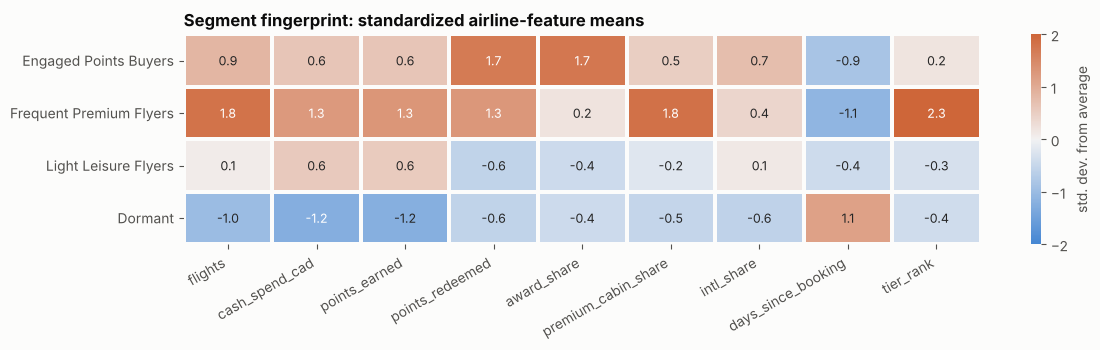

In [16]:
z = pd.DataFrame(X_scaled, columns=cluster_features, index=features.index)
zprof = z.groupby(features["segment"]).mean().loc[SEGMENTS]
fig = plt.figure(figsize=(12, 3.6))
sns.heatmap(zprof, cmap=DIVERGING, center=0, vmin=-2, vmax=2, annot=True, fmt=".1f",
            annot_kws={"size": 9}, linewidths=1.5, linecolor=SURFACE,
            cbar_kws={"label": "std. dev. from average"})
plt.title("Segment fingerprint: standardized airline-feature means"); plt.grid(False)
plt.ylabel(""); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); save(fig, "segment_fingerprint")

### 7c. Activity side by side

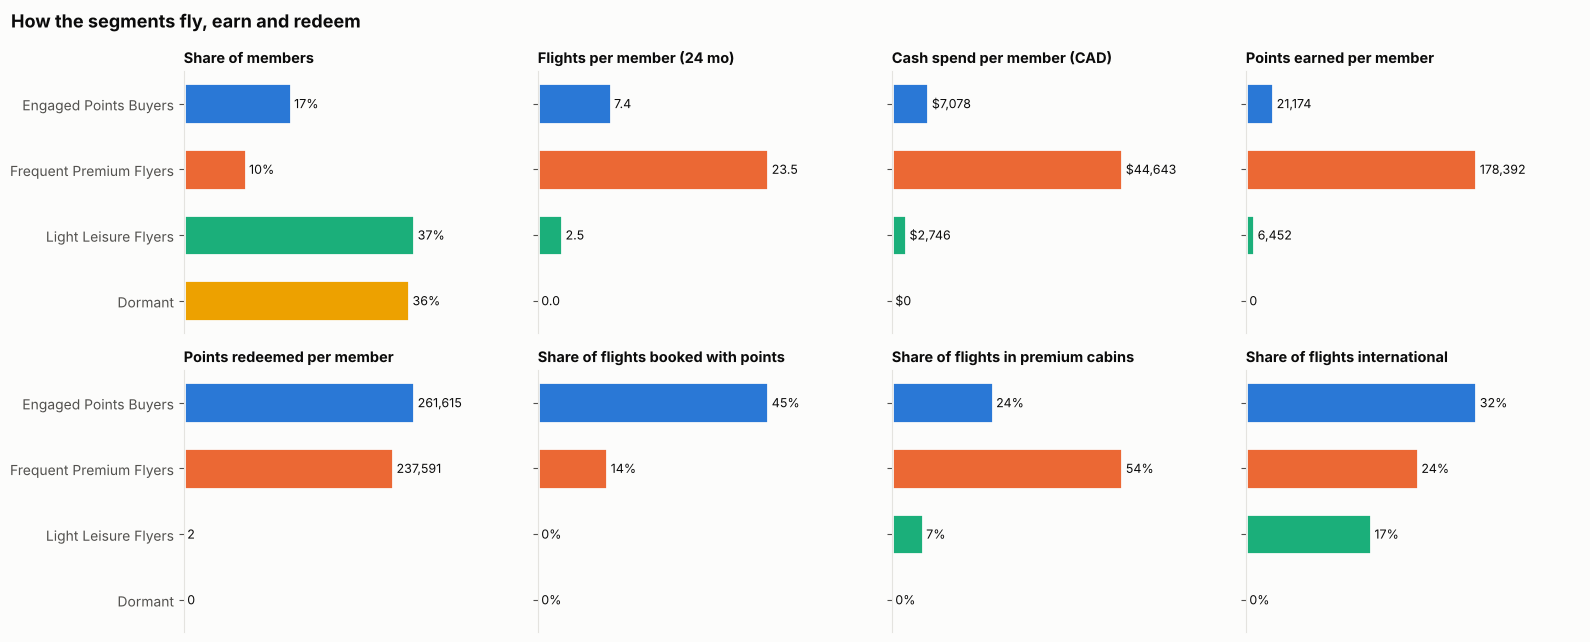

In [17]:
metrics = [
    ("pct_of_base", "Share of members", "{:.0%}"),
    ("flights", "Flights per member (24 mo)", "{:.1f}"),
    ("cash_spend_cad", "Cash spend per member (CAD)", "${:,.0f}"),
    ("points_earned", "Points earned per member", "{:,.0f}"),
    ("points_redeemed", "Points redeemed per member", "{:,.0f}"),
    ("award_share", "Share of flights booked with points", "{:.0%}"),
    ("premium_cabin_share", "Share of flights in premium cabins", "{:.0%}"),
    ("intl_share", "Share of flights international", "{:.0%}"),
]
order = SEGMENTS[::-1]
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), sharey=True)
for ax, (col, title, fmt) in zip(axes.flat, metrics):
    vals = seg_profile.loc[order, col]
    bars = ax.barh(order, vals, color=[SEG_COLOR[s] for s in order], height=0.62,
                   edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + fmt.format(v),
                va="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlim(0, vals.max() * 1.45); ax.set_xticks([]); ax.grid(False)
    ax.spines["bottom"].set_visible(False)
fig.suptitle("How the segments fly, earn and redeem", x=0.01, ha="left", fontweight="bold",
             fontsize=13, color=INK)
plt.tight_layout(); save(fig, "segment_activity")

### 7d. Traits: cabin, route, tier and booking behaviour

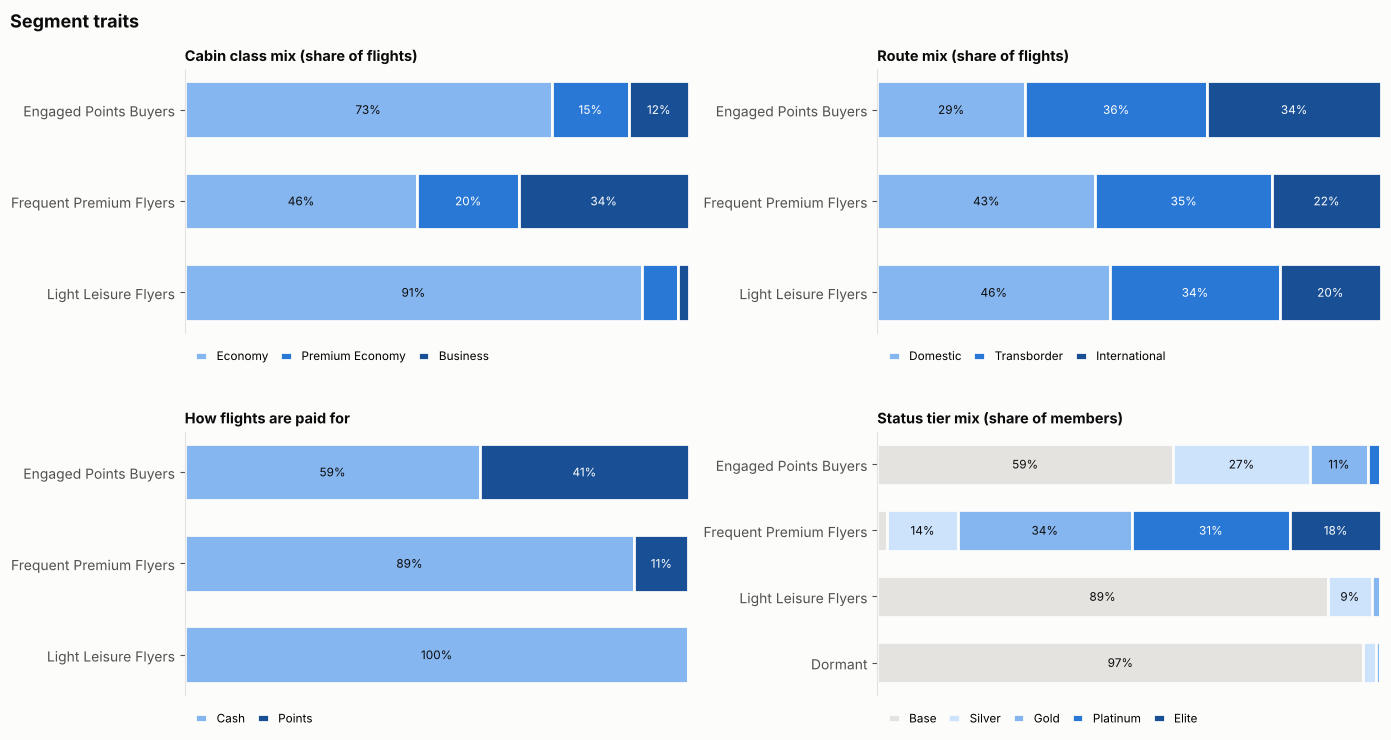

In [18]:
seg_of = features["segment"]
fx = f.assign(segment=f["member_id"].map(seg_of))

def mix(col, cats):
    t = pd.crosstab(fx["segment"], fx[col], normalize="index").reindex(index=SEGMENTS[:-1], columns=cats)
    return t.fillna(0)

cabin = mix("cabin_class", ["Economy", "Premium Economy", "Business"])
route = mix("route_type", ["Domestic", "Transborder", "International"])
tier = (pd.crosstab(features["segment"], features["tier"], normalize="index")
        .reindex(index=SEGMENTS, columns=list(TIER_ORDER)).fillna(0))
pay = mix("payment_type", ["Cash", "Points"])

def stacked(ax, table, title, colors):
    left = np.zeros(len(table))
    for col, c in zip(table.columns, colors):
        w = table[col].to_numpy()
        ax.barh(table.index[::-1], w[::-1], left=left[::-1], color=c, height=0.62,
                edgecolor=SURFACE, linewidth=2, label=col)
        for y, (l, v) in enumerate(zip(left[::-1], w[::-1])):
            if v >= 0.08:
                ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                        color="white" if c in BLUES[2:] else INK)
        left += w
    ax.set_xlim(0, 1); ax.set_xticks([]); ax.grid(False); ax.spines["bottom"].set_visible(False)
    ax.set_title(title, fontsize=10.5)
    ax.legend(ncol=len(table.columns), frameon=False, fontsize=8.5, loc="upper left",
              bbox_to_anchor=(0, -0.02), handlelength=1, columnspacing=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 7.5))
stacked(axes[0, 0], cabin, "Cabin class mix (share of flights)", BLUES[1:])
stacked(axes[0, 1], route, "Route mix (share of flights)", BLUES[1:])
stacked(axes[1, 0], pay, "How flights are paid for", [BLUES[1], BLUES[3]])
stacked(axes[1, 1], tier, "Status tier mix (share of members)", ["#e4e3df"] + BLUES)
fig.suptitle("Segment traits", x=0.01, ha="left", fontweight="bold", fontsize=13, color=INK)
plt.tight_layout(h_pad=3); save(fig, "segment_traits")

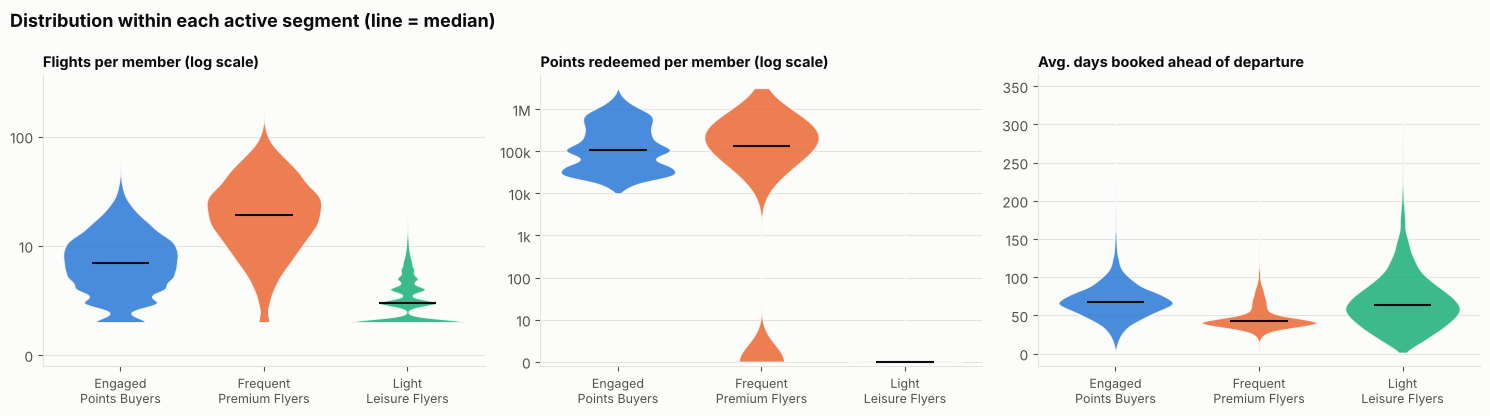

In [19]:
# Distributions, not just averages: how spread out is each segment?
active = features[features["segment"] != "Dormant"]
active_segs = SEGMENTS[:-1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (col, title, log) in zip(axes, [("flights", "Flights per member", True),
                                        ("points_redeemed", "Points redeemed per member", True),
                                        ("avg_lead_days", "Avg. days booked ahead of departure", False)]):
    data = [np.log10(active.loc[active["segment"] == s, col] + 1) if log else
            active.loc[active["segment"] == s, col] for s in active_segs]
    parts = ax.violinplot(data, showmedians=True, showextrema=False, widths=0.8)
    for body, s in zip(parts["bodies"], active_segs):
        body.set_facecolor(SEG_COLOR[s]); body.set_edgecolor(SURFACE); body.set_alpha(0.85)
    parts["cmedians"].set_color(INK); parts["cmedians"].set_linewidth(1.5)
    ax.set_xticks(range(1, len(active_segs) + 1), [s.replace(" ", "\n", 1) for s in active_segs], fontsize=9)
    if log:
        ticks = [0, 1, 2, 3, 4, 5, 6]
        ax.set_yticks(ticks, ["0", "10", "100", "1k", "10k", "100k", "1M"])
        ax.set_ylim(-0.1, max(np.max(d) for d in data) + 0.3)
    ax.set_title(title + (" (log scale)" if log else ""), fontsize=10.5); ax.grid(axis="x", visible=False)
fig.suptitle("Distribution within each active segment (line = median)", x=0.01, ha="left",
             fontweight="bold", fontsize=13, color=INK)
plt.tight_layout(); save(fig, "segment_distributions")

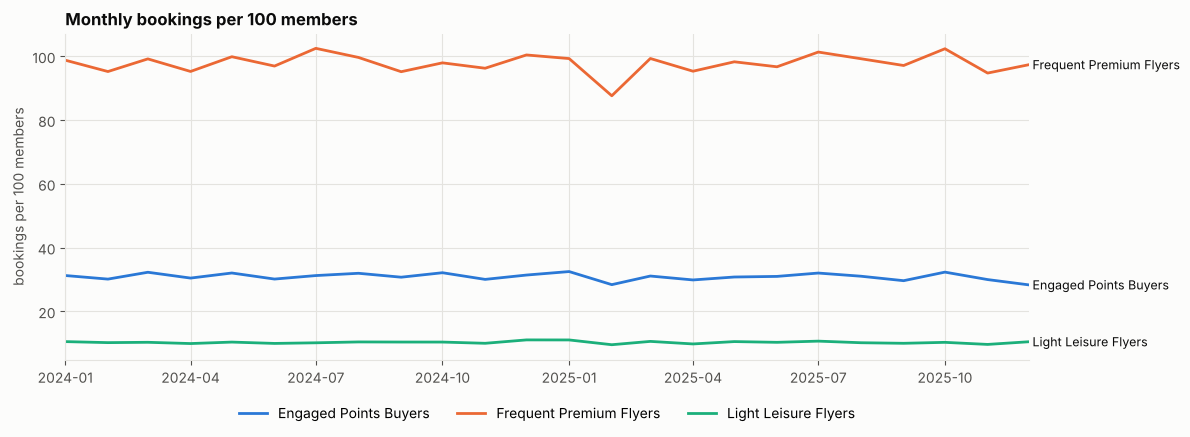

In [20]:
# Activity over time: flights booked per 100 members, by month
monthly = (fx.assign(month=fx["booking_date"].dt.to_period("M").dt.to_timestamp())
           .groupby(["month", "segment"]).size().unstack().reindex(columns=SEGMENTS[:-1]))
monthly = monthly / features["segment"].value_counts()[monthly.columns] * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
for s in monthly.columns:
    ax.plot(monthly.index, monthly[s], color=SEG_COLOR[s], lw=2, label=s)
    ax.annotate(f" {s}", (monthly.index[-1], monthly[s].iloc[-1]), va="center", fontsize=9,
                color=INK, annotation_clip=False)
ax.set(title="Monthly bookings per 100 members", ylabel="bookings per 100 members")
ax.set_xlim(monthly.index[0], monthly.index[-1])
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout(); save(fig, "segment_monthly_activity")

## 8. North-star KPI: share of members who bought points
Points purchases were **not** used to build the segments. If airline engagement drives points buying, the segments should still separate cleanly on this KPI.

In [21]:
kpi = features.groupby("segment").agg(
    members=("bought_points", "size"),
    buyers=("bought_points", "sum"),
    share_bought=("bought_points", "mean"),
    purchases_per_buyer=("purchases", lambda s: s[s > 0].mean()),
    revenue_usd=("purchase_spend_usd", "sum"),
).loc[SEGMENTS]
kpi["share_of_members"] = kpi["members"] / kpi["members"].sum()
kpi["share_of_buyers"] = kpi["buyers"] / kpi["buyers"].sum()
kpi["share_of_revenue"] = kpi["revenue_usd"] / kpi["revenue_usd"].sum()
overall = features["bought_points"].mean()
kpi

,members,buyers,share_bought,purchases_per_buyer,revenue_usd,share_of_members,share_of_buyers,share_of_revenue
segment,,,,,,,,
Engaged Points Buyers,6846,3495,0.51,4.50,"14,075,727.73",0.17,0.50,0.74
Frequent Premium Flyers,3960,1387,0.35,2.98,"3,471,833.74",0.10,0.20,0.18
Light Leisure Flyers,14762,1515,0.10,1.39,"872,220.61",0.37,0.22,0.05
Dormant,14432,624,0.04,1.58,"530,170.37",0.36,0.09,0.03


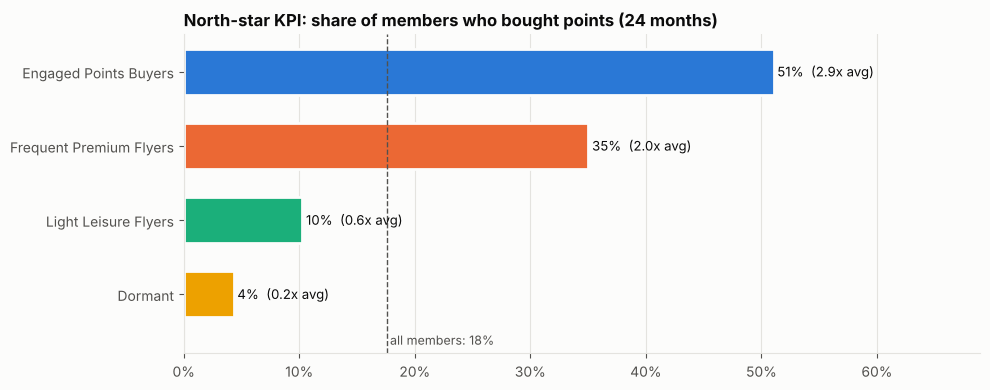

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
order = SEGMENTS[::-1]
bars = ax.barh(order, kpi.loc[order, "share_bought"], color=[SEG_COLOR[s] for s in order],
               height=0.62, edgecolor=SURFACE, linewidth=2)
for b, s in zip(bars, order):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2,
            f" {kpi.loc[s, 'share_bought']:.0%}  ({kpi.loc[s, 'share_bought'] / overall:.1f}x avg)",
            va="center", fontsize=9.5, color=INK)
ax.axvline(overall, color=INK_2, ls="--", lw=1)
ax.text(overall, -0.62, f" all members: {overall:.0%}", color=INK_2, fontsize=9, va="center")
ax.set_ylim(-0.8, len(order) - 0.5)
ax.set_xlim(0, kpi["share_bought"].max() * 1.35)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("North-star KPI: share of members who bought points (24 months)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); save(fig, "kpi_share_bought")

,avg engagement score
segment,
Engaged Points Buyers,1.16
Frequent Premium Flyers,1.15
Light Leisure Flyers,0.01
Dormant,-0.87


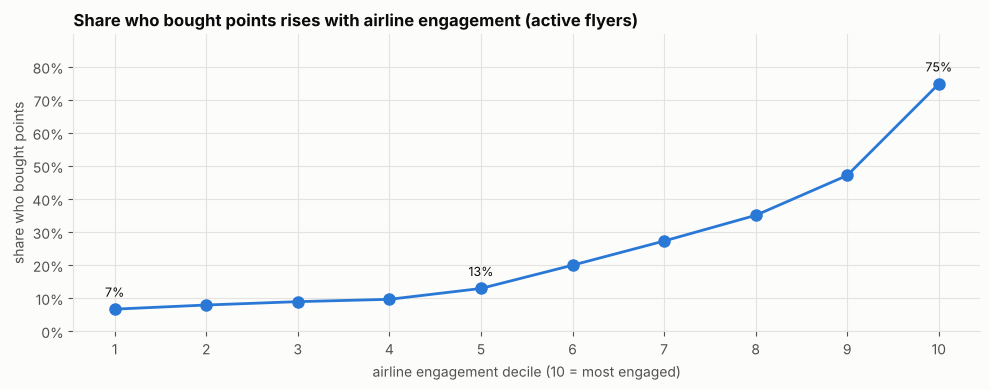

In [23]:
# Same story on a continuous scale: build a simple airline-engagement score
# (average of standardized flights, earning, redeeming, award share and booking recency)
eng_cols = ["flights", "points_earned", "points_redeemed", "award_share", "days_since_booking"]
eng = z[eng_cols].copy()
eng["days_since_booking"] *= -1          # more recent = more engaged
features["engagement_score"] = eng.mean(axis=1)
active = features[features["flights"] > 0].copy()
active["engagement_decile"] = pd.qcut(active["engagement_score"].rank(method="first"), 10, labels=range(1, 11))
by_decile = active.groupby("engagement_decile", observed=True)["bought_points"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_decile.index.astype(int), by_decile.values, marker="o", ms=8, lw=2, color=PALETTE[0])
for x, v in zip(by_decile.index.astype(int), by_decile.values):
    if x in (1, 5, 10):
        ax.annotate(f"{v:.0%}", (x, v), xytext=(0, 9), textcoords="offset points", ha="center",
                    fontsize=9, color=INK)
ax.set(title="Share who bought points rises with airline engagement (active flyers)",
       xlabel="airline engagement decile (10 = most engaged)", ylabel="share who bought points",
       xticks=range(1, 11))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, by_decile.max() * 1.2)
plt.tight_layout(); save(fig, "kpi_by_engagement_decile")
features.groupby("segment")["engagement_score"].mean().loc[SEGMENTS].to_frame("avg engagement score")

*Engaged Points Buyers* and *Frequent Premium Flyers* have similar overall engagement scores, but they are engaged in different ways. Frequent Premium Flyers fly about three times as often but mostly pay cash. Engaged Points Buyers redeem points for nearly half their trips. Engagement through **redemption** is what turns into points buying: their share who bought is roughly 15 points higher.

In [24]:
top = kpi.loc[TOP_SEGMENT]
print(f"{TOP_SEGMENT}: {top['share_of_members']:.0%} of members, {top['share_of_buyers']:.0%} of points buyers, "
      f"{top['share_of_revenue']:.0%} of points revenue")
print(f"Share who bought points: {top['share_bought']:.0%} vs {overall:.0%} for all members "
      f"({top['share_bought'] / overall:.1f}x)")

Engaged Points Buyers: 17% of members, 50% of points buyers, 74% of points revenue
Share who bought points: 51% vs 18% for all members (2.9x)


**Finding:** the segment built purely from airline behaviour has by far the **highest share of members who bought points**. Across active flyers, the share rises steadily with airline engagement. Members who are engaged with the airline, especially those who redeem points for flights, have a higher propensity to buy points.

Even in the top segment, a large share of members have **never bought**. Raising that share is the north-star goal, and those non-buyers are where the opportunity is.

## 9. Ranking the non-buyers: look-alike propensity
Not every non-buyer in the top segment is equally likely to convert. A logistic regression trained on **airline features only** learns what buyers look like. Applied to non-buyers, a high score means *"looks like a buyer, but hasn't bought yet"*.

The model is evaluated on a stratified 30% hold-out. It is a look-alike score, not a causal estimate: it ranks members by similarity to past buyers.

In [25]:
model_features = cluster_features + ["avg_lead_days", "tenure_years"]
def model_matrix(df):
    m = df[model_features].copy()
    m[log_cols] = np.log1p(m[log_cols])
    return m

y = features["bought_points"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(model_matrix(features), y, test_size=0.3,
                                                    stratify=y, random_state=RANDOM_STATE)
lookalike = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
print(f"Hold-out ROC-AUC: {roc_auc_score(y_test, lookalike.predict_proba(X_test)[:, 1]):.3f}")
features["lookalike_score"] = lookalike.predict_proba(model_matrix(features))[:, 1]

Hold-out ROC-AUC: 0.832


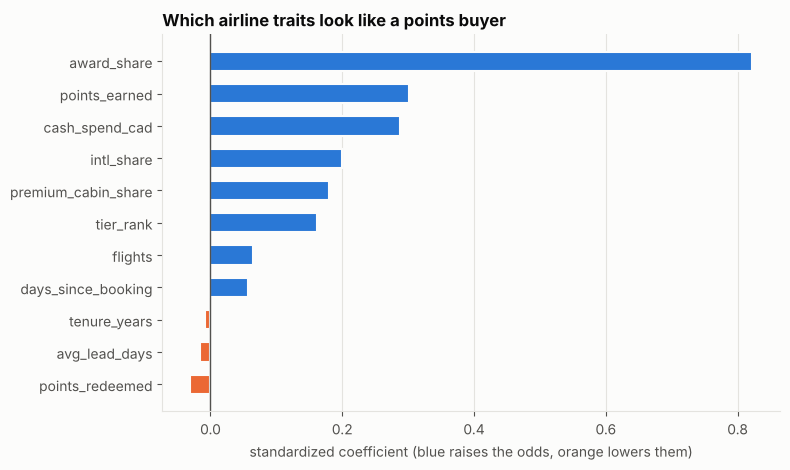

In [26]:
coefs = pd.Series(lookalike[-1].coef_[0], index=model_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(coefs.index, coefs.values, color=[PALETTE[1] if v < 0 else PALETTE[0] for v in coefs],
        height=0.6, edgecolor=SURFACE, linewidth=1.5)
ax.axvline(0, color=INK_2, lw=1)
ax.set(title="Which airline traits look like a points buyer",
       xlabel="standardized coefficient (blue raises the odds, orange lowers them)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); save(fig, "lookalike_drivers")

The share of flights booked with points (**award share**) is by far the strongest airline signal of a points buyer. Members who spend points run their balances down and top up. Overall engagement (points earned, cash spend, international and premium travel, tier) adds to the odds as well.

*Caveat:* several features are highly correlated, e.g. `points_redeemed` with `award_share`, and flights, spend and points earned with each other. The model splits credit between correlated features somewhat arbitrarily. For example, `points_redeemed` shows a small negative weight only because `award_share` already carries the redemption signal. Read the coefficients as groups.

## 10. Target list: lowest-hanging fruit
From the top segment, keep members who:
1. have **never bought points**, and
2. were **never on our email list**, meaning they have never received a points campaign.

They match the profile of our best buyers but have never been asked. They are ranked by look-alike score. The `email_opt_in` flag shows who can be added to email straight away; the rest need another channel, such as on-site offers or in-app messaging.

In [27]:
in_top = features["segment"] == TOP_SEGMENT
never_bought = in_top & ~features["bought_points"]
target_mask = never_bought & ~features["ever_emailed"]

funnel = pd.Series({
    "All members": len(features),
    f"Top segment ({TOP_SEGMENT})": in_top.sum(),
    "  ...never bought points": never_bought.sum(),
    "  ...never emailed (target list)": target_mask.sum(),
}, name="members").to_frame()
funnel["pct_of_previous_step"] = funnel["members"] / funnel["members"].shift()
funnel

,members,pct_of_previous_step
All members,40000,NaN
Top segment (Engaged Points Buyers),6846,0.17
...never bought points,3351,0.49
...never emailed (target list),2443,0.73


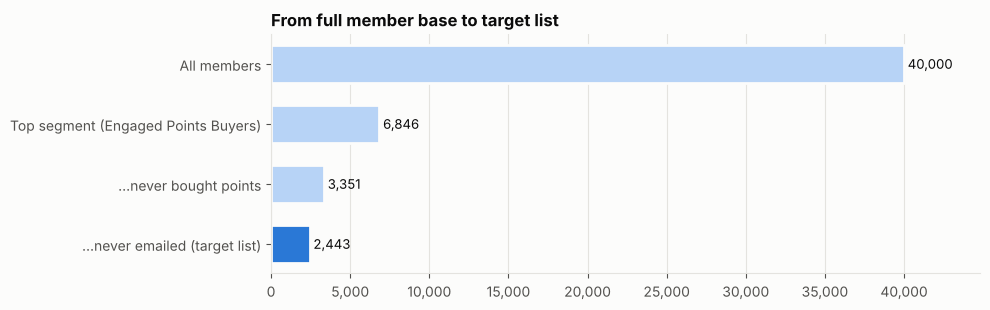

In [28]:
fig, ax = plt.subplots(figsize=(10, 3.2))
labels, vals = funnel.index[::-1], funnel["members"].iloc[::-1]
bars = ax.barh(labels, vals, color=[PALETTE[0]] + ["#b7d3f6"] * 3, height=0.62,
               edgecolor=SURFACE, linewidth=2)
for b, v in zip(bars, vals):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f" {v:,}", va="center", fontsize=9.5, color=INK)
ax.set_xlim(right=vals.max() * 1.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("From full member base to target list"); ax.grid(axis="y", visible=False)
plt.tight_layout(); save(fig, "target_funnel")

In [29]:
# The target list looks like the segment's buyers on the airline side, but it has no purchase history
compare = pd.DataFrame({
    "Top-segment buyers": features[in_top & features["bought_points"]][cluster_features].mean(),
    "Target list": features[target_mask][cluster_features].mean(),
    "All members": features[cluster_features].mean(),
})
compare.loc["lookalike_score"] = [features.loc[in_top & features["bought_points"], "lookalike_score"].mean(),
                                  features.loc[target_mask, "lookalike_score"].mean(),
                                  features["lookalike_score"].mean()]
compare

,Top-segment buyers,Target list,All members
flights,8.77,5.93,4.50
cash_spend_cad,"8,181.35","5,871.30","6,644.65"
points_earned,"26,604.01","15,350.37","23,666.03"
points_redeemed,"410,720.43","100,648.55","68,297.52"
award_share,0.53,0.37,0.09
premium_cabin_share,0.33,0.13,0.12
intl_share,0.37,0.26,0.14
days_since_booking,115.93,151.48,389.64
tier_rank,0.84,0.30,0.41
lookalike_score,0.60,0.37,0.18


In [30]:
target_list = (features[target_mask]
               .assign(priority=lambda d: pd.qcut(d["lookalike_score"].rank(method="first", ascending=False),
                                                  3, labels=["High", "Medium", "Low"]))
               .sort_values("lookalike_score", ascending=False)
               [["segment", "tier", "lookalike_score", "priority", "email_opt_in", "flights",
                 "points_earned", "points_redeemed", "award_share", "points_balance", "home_airport"]]
               .round({"lookalike_score": 4, "award_share": 2}))

Path("output").mkdir(exist_ok=True)
target_list.to_csv("output/target_list.csv")
features[["segment", "engagement_score", "lookalike_score", "bought_points", "ever_emailed",
          "email_opt_in"]].round(4).to_csv("output/member_segments.csv")
print(f"Saved {len(target_list):,} members to output/target_list.csv")
target_list.head(10)

Saved 2,443 members to output/target_list.csv


,segment,tier,lookalike_score,priority,email_opt_in,flights,points_earned,points_redeemed,award_share,points_balance,home_airport
member_id,,,,,,,,,,,
M0013175,Engaged Points Buyers,Platinum,0.93,High,False,1.00,0.00,"183,400.00",1.00,0,YEG
M0031948,Engaged Points Buyers,Platinum,0.91,High,True,23.00,"15,052.00","1,568,900.00",0.87,0,YYZ
M0028449,Engaged Points Buyers,Silver,0.90,High,True,1.00,0.00,"174,000.00",1.00,0,YVR
M0013751,Engaged Points Buyers,Base,0.89,High,False,8.00,"9,058.00","613,900.00",0.88,0,YYC
M0029674,Engaged Points Buyers,Base,0.89,High,False,1.00,0.00,"89,400.00",1.00,0,YUL
M0004616,Engaged Points Buyers,Base,0.89,High,True,1.00,0.00,"228,200.00",1.00,0,YYZ
M0024383,Engaged Points Buyers,Gold,0.89,High,True,4.00,"37,199.00","662,200.00",0.75,0,YOW
M0035228,Engaged Points Buyers,Base,0.89,High,False,1.00,0.00,"230,300.00",1.00,0,YWG
M0006218,Engaged Points Buyers,Gold,0.89,High,True,8.00,"42,305.00","697,200.00",0.75,0,YHZ


In [31]:
target_list.groupby("priority", observed=True).agg(
    members=("lookalike_score", "size"),
    avg_score=("lookalike_score", "mean"),
    email_opt_in=("email_opt_in", "mean"),
    avg_points_redeemed=("points_redeemed", "mean"),
)

,members,avg_score,email_opt_in,avg_points_redeemed
priority,,,,
High,815,0.59,0.69,"169,596.69"
Medium,814,0.31,0.71,"82,518.18"
Low,814,0.21,0.71,"49,746.07"


In [32]:
# What the target list is worth to the north-star KPI
seg_size, seg_buyers = in_top.sum(), (in_top & features["bought_points"]).sum()
rows = []
for conv in [0.05, 0.10, 0.15, 0.20]:
    new = round(len(target_list) * conv)
    rows.append({"conversion of target list": f"{conv:.0%}", "new buyers": new,
                 "top-segment share bought": (seg_buyers + new) / seg_size,
                 "overall share bought": (features["bought_points"].sum() + new) / len(features)})
pd.DataFrame(rows).set_index("conversion of target list")

,new buyers,top-segment share bought,overall share bought
conversion of target list,,,
5%,122,0.53,0.18
10%,244,0.55,0.18
15%,366,0.56,0.18
20%,489,0.58,0.19


## 11. Takeaways & recommendations
- **Airline engagement predicts points buying.** The segments were built only from airline data, yet *Engaged Points Buyers* have the highest share of members who bought points, well above the average. Share bought also rises steadily with an airline-engagement score.
- **Redemption is the link.** The top segment's defining trait is booking award flights. Members who spend points run their balances down and top up.
- **Share of members who bought points is the north-star KPI.** Even in the best segment a large share has never bought, so there is room to grow.
- **Lowest-hanging fruit:** top-segment members who have **never bought** and were **never on our email list**. They look like our buyers but have never been asked. Each 5 points of conversion on this list moves the segment KPI noticeably (see the table above).
- **Execution:**
  - Add opted-in members to the next points campaign, starting with the *High* priority tier.
  - Reach the rest through other channels (on-site or in-app offers after an award search).
  - Lead with redemption messaging, e.g. "top up to book your next award trip".
  - Keep a random holdout in each tier to measure incremental lift.
- **Other segments:** *Frequent Premium Flyers* earn enough to rarely need points, so status or upgrade offers fit better. *Light Leisure* and *Dormant* members need engagement and reactivation before a points sale makes sense.